<a href="https://colab.research.google.com/github/Abbhiiraamii/financial-time-series-cnn/blob/main/stock_price_prediction_stft_cnn_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance scipy scikit-learn

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

In [3]:
stocks = ["RELIANCE.NS","TCS.NS","INFY.NS"]

data = yf.download(stocks, start="2019-01-01", end="2024-01-01")

price = data["Close"]

price.head()

/tmp/ipykernel_11585/3378287992.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  3 of 3 completed


Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2019-01-01,553.448364,498.490601,1582.166382
2019-01-02,556.777283,491.998230,1599.211670
2019-01-03,556.860352,485.928284,1579.796143
2019-01-04,550.119629,488.551910,1560.588745
2019-01-07,558.982666,491.264496,1578.091919


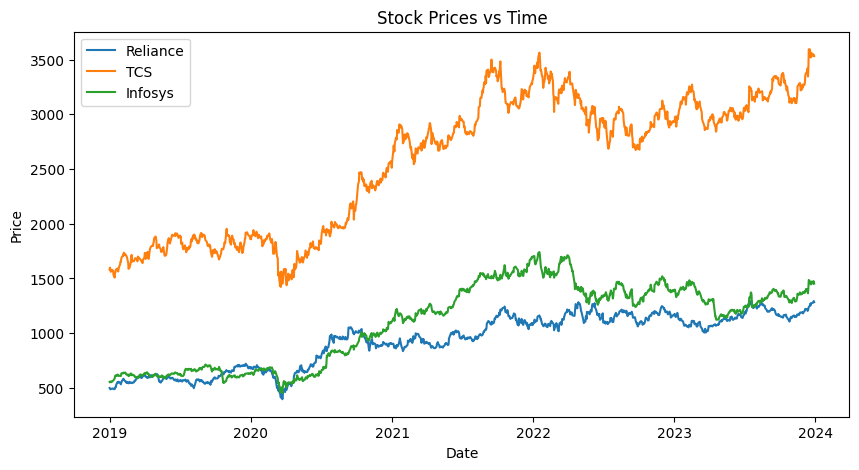

In [4]:
plt.figure(figsize=(10,5))

plt.plot(price.index, price["RELIANCE.NS"], label="Reliance")
plt.plot(price.index, price["TCS.NS"], label="TCS")
plt.plot(price.index, price["INFY.NS"], label="Infosys")

plt.title("Stock Prices vs Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

In [5]:
signal = price["RELIANCE.NS"].values

In [6]:
scaler = StandardScaler()

signal = scaler.fit_transform(signal.reshape(-1,1)).flatten()

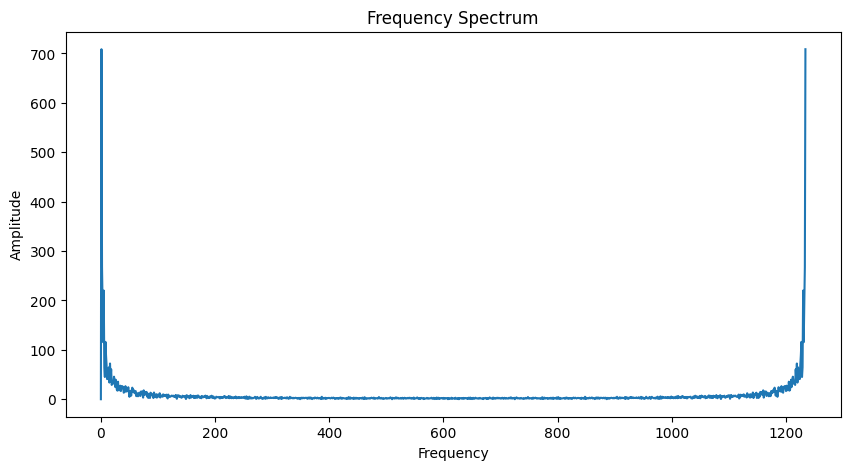

In [7]:
spectrum = fft(signal)

plt.figure(figsize=(10,5))
plt.plot(np.abs(spectrum))

plt.title("Frequency Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")

plt.show()

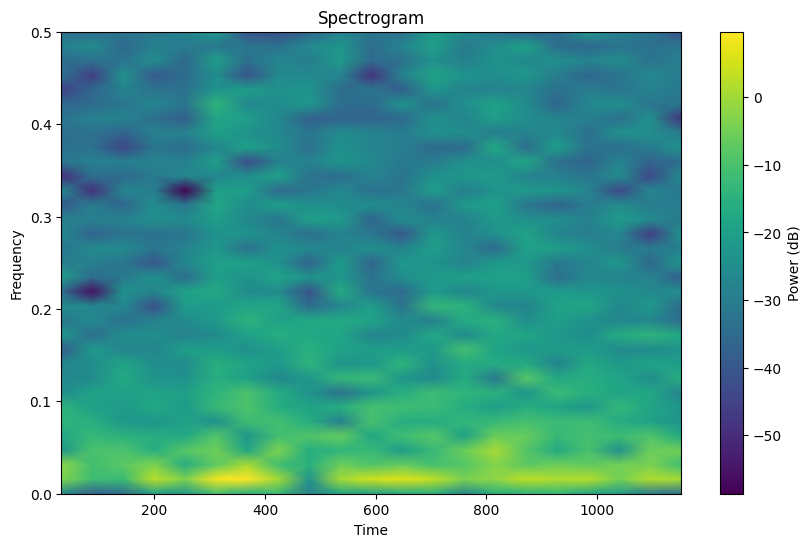

In [8]:
frequencies, times, Sxx = spectrogram(signal, nperseg=64)

Sxx_log = 10*np.log10(Sxx + 1e-10)

plt.figure(figsize=(10,6))

plt.pcolormesh(times, frequencies, Sxx_log, shading='gouraud')

plt.ylabel("Frequency")
plt.xlabel("Time")
plt.title("Spectrogram")

plt.colorbar(label="Power (dB)")

plt.show()

In [9]:
X = Sxx.reshape(1, Sxx.shape[0], Sxx.shape[1], 1)

y = np.array([signal[-1]])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1, 33, 21, 1)
y shape: (1,)


In [10]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=X.shape[1:]),

    tf.keras.layers.Conv2D(16,(3,3),activation='relu',padding='same'),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='same'),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(32,activation='relu'),

    tf.keras.layers.Dense(1)
])

In [11]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [12]:
model.fit(X, y, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 2.2563
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 1.2753
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - loss: 0.7559
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.3689
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.1027
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 2.1514e-04
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0771
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.2225
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2851
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.2448


In [13]:
prediction = model.predict(X)

print("Predicted price:", prediction)
print("Actual price:", y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted price: [[1.8348997]]
Actual price: [1.43915449]


In [14]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, prediction)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.15661423968824026
